**Task 1: Data Preparation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training set: (17000, 28, 28, 1) (17000, 10)
Testing set: (3000, 28, 28, 1) (3000, 10)


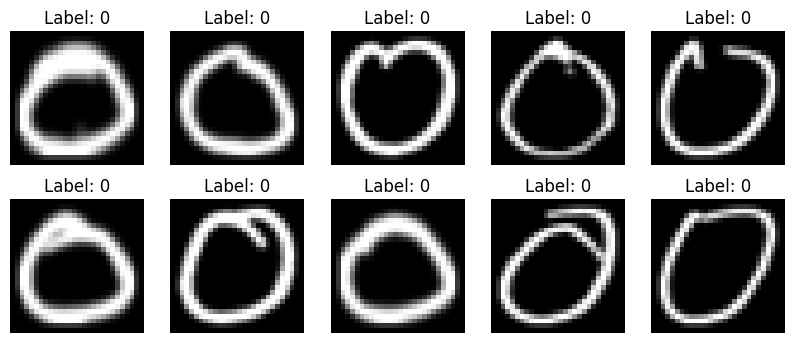

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset paths
train_dir = "/content/drive/MyDrive/Concept of Technologies and AI/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Concept of Technologies and AI/DevanagariHandwrittenDigitDataset/Test"

# Image size
img_height, img_width = 28, 28

# Function to load images
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print shapes
print("Training set:", x_train.shape, y_train.shape)
print("Testing set:", x_test.shape, y_test.shape)

# Visualization
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

**Task 2: Build the FCN Model**

In [3]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28, 1)),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Compile the Model**

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Train the Model**

Epoch 1/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2935 - loss: 1.9930

107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5181 - loss: 1.5906 - val_accuracy: 0.0000e+00 - val_loss: 7.2345
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8317 - loss: 0.4885 - val_accuracy: 0.0000e+00 - val_loss: 8.7123
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2809 - val_accuracy: 0.0000e+00 - val_loss: 9.1252
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9468 - loss: 0.1852 - val_accuracy: 0.0000e+00 - val_loss: 9.3032


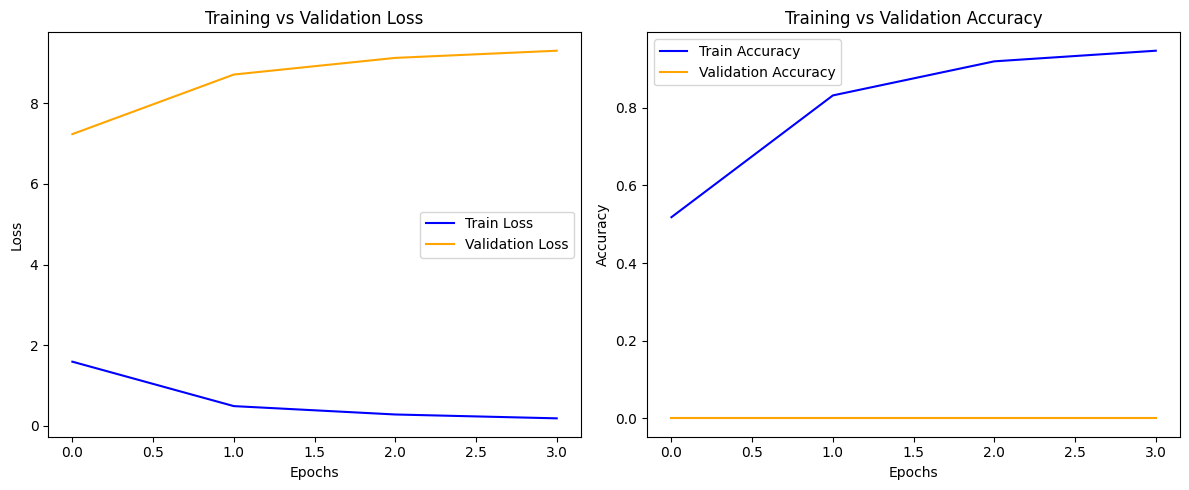

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3),
    keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss',      color='blue')
plt.plot(val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy',      color='blue')
plt.plot(val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7593 - loss: 2.0046

Test Loss:     2.0046
Test Accuracy: 0.7593


**Task 6: Save and Load the Model**

In [7]:
# Save
model.save('devnagari_fcn_model.h5')
print("Model saved!")

# Load
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded!")

# Re-evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model — Test Accuracy: {acc:.4f}")

Model saved!
Model loaded!
94/94 - 1s - 6ms/step - accuracy: 0.7593 - loss: 2.0046
Loaded Model — Test Accuracy: 0.7593


In [8]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual   :", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual   : [0 0 0 0 0 0 0 0 0 0]


In [9]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual   :", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual   : [0 0 0 0 0 0 0 0 0 0]


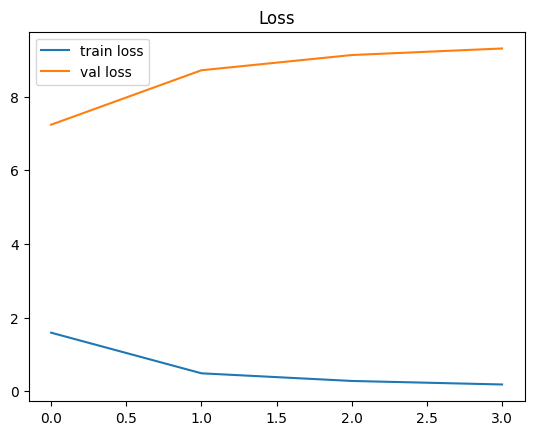

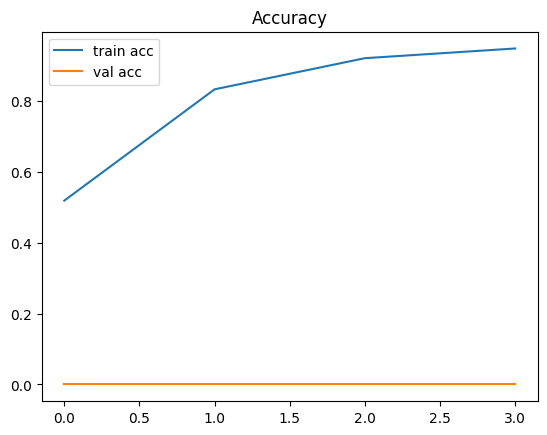

In [10]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()